<a href="https://colab.research.google.com/github/nguyentrongnguyen3004-eng/DeepLearning_Chest_X_Ray/blob/main/DeepLearning_Chest_X_Ray_Resnet18.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("paultimothymooney/chest-xray-pneumonia")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'chest-xray-pneumonia' dataset.
Path to dataset files: /kaggle/input/chest-xray-pneumonia


In [4]:
import os

# Đường dẫn đến thư mục chứa dữ liệu chính đã được hiển thị trong hình của bạn
base_path = '/kaggle/input/chest-xray-pneumonia/chest_xray'

# Danh sách các thư mục cần đếm
folders = ['train', 'test', 'val']

print("=== THỐNG KÊ SỐ LƯỢNG ẢNH ===")

for folder in folders:
    folder_path = os.path.join(base_path, folder)
    print(f"\nThư mục: {folder}")

    total_images_in_folder = 0

    # Kiểm tra xem thư mục có tồn tại không
    if os.path.exists(folder_path):
        # Lấy danh sách các thư mục con (các nhãn/class)
        classes = os.listdir(folder_path)

        for class_name in classes:
            class_path = os.path.join(folder_path, class_name)

            # Chỉ đếm trong các thư mục hợp lệ (bỏ qua file rác hoặc __MACOSX nếu có)
            if os.path.isdir(class_path) and not class_name.startswith('.'):
                # Đếm số file trong thư mục class này
                num_images = len(os.listdir(class_path))
                print(f"  - Lớp '{class_name}': {num_images} ảnh")
                total_images_in_folder += num_images

        print(f"  => Tổng cộng tập {folder}: {total_images_in_folder} ảnh")
    else:
        print("  Không tìm thấy thư mục này.")

=== THỐNG KÊ SỐ LƯỢNG ẢNH ===

Thư mục: train
  - Lớp 'PNEUMONIA': 3875 ảnh
  - Lớp 'NORMAL': 1341 ảnh
  => Tổng cộng tập train: 5216 ảnh

Thư mục: test
  - Lớp 'PNEUMONIA': 390 ảnh
  - Lớp 'NORMAL': 234 ảnh
  => Tổng cộng tập test: 624 ảnh

Thư mục: val
  - Lớp 'PNEUMONIA': 8 ảnh
  - Lớp 'NORMAL': 8 ảnh
  => Tổng cộng tập val: 16 ảnh


**1. Tái cấu trúc và phân chia lại các tập dữ liệu**

In [5]:

import os
import shutil
import random
import warnings
import numpy as np
import torch

warnings.filterwarnings("ignore")

# 1. Cố định Seed để đảm bảo tính tái lập (Reproducibility)
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True

# 2. Xử lý đường dẫn động từ kagglehub
base_path = "/kaggle/input/chest-xray-pneumonia"

# Kiểm tra cấu trúc thư mục thực tế để định tuyến DATA_ROOT chính xác
if os.path.exists(os.path.join(base_path, "chest_xray", "train")):
    DATA_ROOT = os.path.join(base_path, "chest_xray")
elif os.path.exists(os.path.join(base_path, "train")):
    DATA_ROOT = base_path
else:
    raise FileNotFoundError(f"❌ Không tìm thấy thư mục 'train' bên trong {base_path}. Vui lòng kiểm tra lại quá trình tải dữ liệu.")

print(f"✅ Đã xác định đường dẫn dữ liệu gốc: {DATA_ROOT}")

# Các đường dẫn lưu trữ đầu ra (nằm trên ổ đĩa có quyền ghi của Colab)
RESPLIT_ROOT = "./chest_xray_resplit"
SAVE_PATH    = "./best_model.pth"
IMAGE_SIZE   = 224
BATCH_SIZE   = 32
VAL_SPLIT    = 0.2

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"✅ Đang sử dụng thiết bị tính toán: {device}")

def resplit_dataset(data_root, resplit_root, val_split=0.2, seed=42):
    random.seed(seed)
    if os.path.exists(resplit_root):
        print(f"⚠️ Thư mục '{resplit_root}' đã tồn tại. Bỏ qua bước sao chép vật lý.")
        return None

    classes = ["NORMAL", "PNEUMONIA"]
    print("\n📂 Đang tiến hành gộp và phân chia lại dữ liệu...")
    all_paths = {cls: [] for cls in classes}

    # Gộp ảnh từ Train và Val gốc
    for split in ["train", "val"]:
        for cls in classes:
            folder = os.path.join(data_root, split, cls)
            if not os.path.exists(folder): continue
            files = [os.path.join(folder, f) for f in os.listdir(folder) if f.lower().endswith((".jpeg", ".jpg", ".png"))]
            all_paths[cls].extend(files)

    # Khởi tạo thư mục đích
    for split in ["train", "val", "test"]:
        for cls in classes:
            os.makedirs(os.path.join(resplit_root, split, cls), exist_ok=True)

    # Chia lại tỷ lệ (Train/Val)
    for cls in classes:
        paths = all_paths[cls]
        random.shuffle(paths)
        n_val = int(len(paths) * val_split)
        n_train = len(paths) - n_val
        split_map = {"train": paths[:n_train], "val": paths[n_train:]}

        for split_name, file_list in split_map.items():
            for src in file_list:
                dst = os.path.join(resplit_root, split_name, cls, os.path.basename(src))
                shutil.copy2(src, dst)
        print(f"   [{cls}] Train: {n_train} | Val: {n_val}")

    # Giữ nguyên tập Test để benchmark
    for cls in classes:
        src_dir = os.path.join(data_root, "test", cls)
        dst_dir = os.path.join(resplit_root, "test", cls)
        if os.path.exists(src_dir):
            for f in os.listdir(src_dir):
                if f.lower().endswith((".jpeg", ".jpg", ".png")):
                    shutil.copy2(os.path.join(src_dir, f), os.path.join(dst_dir, f))

    print(f"✅ Hoàn tất thiết lập tại: {resplit_root}")
    return True

# Thực thi logic
resplit_dataset(DATA_ROOT, RESPLIT_ROOT, val_split=VAL_SPLIT)

# Tính toán Class Weights phục vụ cho hàm Mất mát (Loss function)
n_normal = len(os.listdir(os.path.join(RESPLIT_ROOT, "train", "NORMAL")))
n_pneumonia = len(os.listdir(os.path.join(RESPLIT_ROOT, "train", "PNEUMONIA")))
total = n_normal + n_pneumonia

weight_normal = total / (2 * n_normal)
weight_pneumonia = total / (2 * n_pneumonia)

print(f"\n📊 Trọng số phân lớp (Class Weights):")
print(f"   NORMAL: {weight_normal:.4f} | PNEUMONIA: {weight_pneumonia:.4f}")

✅ Đã xác định đường dẫn dữ liệu gốc: /kaggle/input/chest-xray-pneumonia/chest_xray
✅ Đang sử dụng thiết bị tính toán: cpu

📂 Đang tiến hành gộp và phân chia lại dữ liệu...
   [NORMAL] Train: 1080 | Val: 269
   [PNEUMONIA] Train: 3107 | Val: 776
✅ Hoàn tất thiết lập tại: ./chest_xray_resplit

📊 Trọng số phân lớp (Class Weights):
   NORMAL: 1.9384 | PNEUMONIA: 0.6738


**2. Tiền xử lý và Tăng cường Dữ liệu**

In [6]:

from torchvision import transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader, WeightedRandomSampler

# Thông số chuẩn hóa (Z-score) theo phân phối của tập ImageNet
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

# Transform cho tập Huấn luyện (Train)
train_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.RandomCrop(IMAGE_SIZE),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=5),
    transforms.ColorJitter(brightness=0.15, contrast=0.15),
    transforms.RandomAffine(degrees=0, translate=(0.05, 0.05), scale=(0.9, 1.1)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

# Transform cho tập Kiểm định/Kiểm tra (Val/Test) - Đảm bảo tính khách quan
val_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

# Ánh xạ thư mục thành các đối tượng Dataset
train_dataset = ImageFolder(root=os.path.join(RESPLIT_ROOT, "train"), transform=train_transform)
val_dataset   = ImageFolder(root=os.path.join(RESPLIT_ROOT, "val"),   transform=val_transform)
test_dataset  = ImageFolder(root=os.path.join(RESPLIT_ROOT, "test"),  transform=val_transform)

print(f"📂 Chỉ mục phân lớp: {train_dataset.classes} tương ứng (0, 1)")
print(f"   Tập Train: {len(train_dataset)} mẫu")
print(f"   Tập Val  : {len(val_dataset)} mẫu")
print(f"   Tập Test : {len(test_dataset)} mẫu")

# Xây dựng bộ lấy mẫu có trọng số (Weighted Sampler) để cân bằng tần suất xuất hiện batch
sample_weights = [weight_normal if label == 0 else weight_pneumonia for _, label in train_dataset.samples]
sampler = WeightedRandomSampler(weights=sample_weights, num_samples=len(sample_weights), replacement=True)

# Khởi tạo DataLoader phục vụ tiến trình truyền dữ liệu vào RAM/VRAM
num_workers_colab = 2 # Colab thông thường tối ưu với 2 workers
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, sampler=sampler, num_workers=num_workers_colab, pin_memory=True)
val_loader   = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=num_workers_colab, pin_memory=True)
test_loader  = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=num_workers_colab, pin_memory=True)

print("✅ Hệ thống truyền tải dữ liệu (DataLoader) đã sẵn sàng.")

📂 Chỉ mục phân lớp: ['NORMAL', 'PNEUMONIA'] tương ứng (0, 1)
   Tập Train: 4187 mẫu
   Tập Val  : 1045 mẫu
   Tập Test : 624 mẫu
✅ Hệ thống truyền tải dữ liệu (DataLoader) đã sẵn sàng.


**3. Cấu trúc Mô hình, Huấn luyện và Đánh giá**

In [10]:

import torch.nn as nn
from torchvision import models
from sklearn.metrics import classification_report, confusion_matrix

MODEL_NAME = "resnet18"
DROPOUT_RATE = 0.4
NUM_EPOCHS_PHASE1 = 10
NUM_EPOCHS_PHASE2 = 10

class PneumoniaResNet(nn.Module):
    def __init__(self, model_name="resnet50", dropout_rate=0.4, freeze_backbone=True):
        super(PneumoniaResNet, self).__init__()

        # Tải trọng số Pre-trained IMAGENET1K_V1
        if model_name == "resnet18":
            backbone = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
            num_features = 512
        elif model_name == "resnet34":
            backbone = models.resnet34(weights=models.ResNet34_Weights.IMAGENET1K_V1)
            num_features = 512
        elif model_name == "resnet50":
            backbone = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)
            num_features = 2048

        # Áp dụng chiến lược đóng băng (Freeze parameters)
        if freeze_backbone:
            for param in backbone.parameters():
                param.requires_grad = False

        # Tách cấu trúc: Trích xuất đặc trưng (Feature Extractor)
        self.feature_extractor = nn.Sequential(*list(backbone.children())[:-1])

        # Tái thiết kế đầu ra (Classification Head) cho bài toán nhị phân
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(p=dropout_rate),
            nn.Linear(num_features, 1) # Không qua Sigmoid để phù hợp với BCEWithLogitsLoss
        )

    def forward(self, x):
        features = self.feature_extractor(x)
        logits   = self.classifier(features)
        return logits

    def unfreeze_backbone(self):
        for param in self.feature_extractor.parameters():
            param.requires_grad = True

# Khởi tạo Mô hình và ánh xạ lên GPU
model = PneumoniaResNet(model_name=MODEL_NAME, dropout_rate=DROPOUT_RATE, freeze_backbone=True).to(device)

# Thiết lập Hàm mất mát (Tính toán pos_weight để xử lý triệt để FN)
pos_weight = torch.tensor([weight_pneumonia / weight_normal]).to(device)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

# Định nghĩa các hàm huấn luyện (Training loop abstraction)
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for images, labels in loader:
        images, labels = images.to(device), labels.float().unsqueeze(1).to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * images.size(0)
        preds = (torch.sigmoid(outputs) >= 0.5).float()
        correct += (preds == labels).sum().item()
        total += images.size(0)
    return total_loss / total, correct / total

def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.float().unsqueeze(1).to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            total_loss += loss.item() * images.size(0)
            preds = (torch.sigmoid(outputs) >= 0.5).float()
            correct += (preds == labels).sum().item()
            total += images.size(0)
    return total_loss / total, correct / total

# THỰC THI GIAI ĐOẠN 1: HUẤN LUYỆN CLASSIFICATION HEAD
print("\n🚀 BẮT ĐẦU GIAI ĐOẠN 1: Warm-up Head (Backbone Frozen)")
optimizer = torch.optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=1e-3, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)

best_val_loss = float("inf")
for epoch in range(1, NUM_EPOCHS_PHASE1 + 1):
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_acc = evaluate(model, val_loader, criterion, device)
    scheduler.step(val_loss)

    saved_flag = ""
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), SAVE_PATH)
        saved_flag = " 💾 [Đã lưu trọng số]"

    print(f"Epoch {epoch:02d}/{NUM_EPOCHS_PHASE1} | Train Loss: {train_loss:.4f} (Acc: {train_acc:.2f}) | Val Loss: {val_loss:.4f} (Acc: {val_acc:.2f}){saved_flag}")

# THỰC THI GIAI ĐOẠN 2: FINE-TUNING TOÀN BỘ MẠNG
print("\n🔥 BẮT ĐẦU GIAI ĐOẠN 2: Fine-Tuning (Backbone Unfrozen)")
model.load_state_dict(torch.load(SAVE_PATH, map_location=device)) # Phục hồi điểm cực tiểu cục bộ tốt nhất GĐ1
model.unfreeze_backbone()

# Thiết lập Learning Rate phân tầng (Differential Learning Rates)
optimizer_ft = torch.optim.Adam([
    {"params": model.feature_extractor.parameters(), "lr": 1e-5}, # LR cực nhỏ để bảo vệ feature map
    {"params": model.classifier.parameters(),        "lr": 1e-4},
], weight_decay=1e-4)
scheduler_ft = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer_ft, T_max=NUM_EPOCHS_PHASE2, eta_min=1e-7)

best_val_loss_ft = float("inf")
for epoch in range(1, NUM_EPOCHS_PHASE2 + 1):
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer_ft, device)
    val_loss, val_acc = evaluate(model, val_loader, criterion, device)
    scheduler_ft.step()

    saved_flag = ""
    if val_loss < best_val_loss_ft:
        best_val_loss_ft = val_loss
        torch.save(model.state_dict(), SAVE_PATH)
        saved_flag = " 💾 [Đã lưu trọng số]"

    print(f"Epoch {epoch:02d}/{NUM_EPOCHS_PHASE2} | Train Loss: {train_loss:.4f} (Acc: {train_acc:.2f}) | Val Loss: {val_loss:.4f} (Acc: {val_acc:.2f}){saved_flag}")

# KIỂM ĐỊNH LÂM SÀNG: ĐÁNH GIÁ TRÊN TẬP TEST KÍN
print("\n📊 ĐÁNH GIÁ CHỈ SỐ Y KHOA TRÊN TẬP TEST")
model.load_state_dict(torch.load(SAVE_PATH, map_location=device))
model.eval()

all_preds, all_labels = [], []
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        probs = torch.sigmoid(outputs).squeeze().cpu().numpy()
        preds = (probs >= 0.5).astype(int)

        all_preds.extend(preds.tolist() if probs.ndim > 0 else [preds.item()])
        all_labels.extend(labels.numpy().tolist())

print("\nBáo cáo Phân loại (Classification Report):")
print(classification_report(all_labels, all_preds, target_names=["NORMAL", "PNEUMONIA"], digits=4))

cm = confusion_matrix(all_labels, all_preds)
print(f"Ma trận nhầm lẫn (Confusion Matrix):")
print(f"  [[TN={cm[0,0]}  FP={cm[0,1]}]")
print(f"   [FN={cm[1,0]}  TP={cm[1,1]}]]")

TP, FN = cm[1, 1], cm[1, 0]
FP, TN = cm[0, 1], cm[0, 0]
sensitivity = TP / (TP + FN) if (TP + FN) > 0 else 0
specificity = TN / (TN + FP) if (TN + FP) > 0 else 0

print(f"\n🔬 Độ nhạy (Sensitivity/Recall Pneumonia) : {sensitivity:.4f}")
print(f"🔬 Độ đặc hiệu (Specificity/Recall Normal): {specificity:.4f}")

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 252MB/s]



🚀 BẮT ĐẦU GIAI ĐOẠN 1: Warm-up Head (Backbone Frozen)
Epoch 01/10 | Train Loss: 0.2771 (Acc: 0.69) | Val Loss: 0.2702 (Acc: 0.58) 💾 [Đã lưu trọng số]
Epoch 02/10 | Train Loss: 0.2038 (Acc: 0.81) | Val Loss: 0.2958 (Acc: 0.56)
Epoch 03/10 | Train Loss: 0.1935 (Acc: 0.82) | Val Loss: 0.3509 (Acc: 0.50)
Epoch 04/10 | Train Loss: 0.1913 (Acc: 0.82) | Val Loss: 0.3150 (Acc: 0.56)
Epoch 05/10 | Train Loss: 0.1819 (Acc: 0.84) | Val Loss: 0.3330 (Acc: 0.54)
Epoch 06/10 | Train Loss: 0.1698 (Acc: 0.85) | Val Loss: 0.2995 (Acc: 0.60)
Epoch 07/10 | Train Loss: 0.1749 (Acc: 0.84) | Val Loss: 0.2879 (Acc: 0.62)
Epoch 08/10 | Train Loss: 0.1774 (Acc: 0.85) | Val Loss: 0.2144 (Acc: 0.73) 💾 [Đã lưu trọng số]
Epoch 09/10 | Train Loss: 0.1604 (Acc: 0.86) | Val Loss: 0.2948 (Acc: 0.61)
Epoch 10/10 | Train Loss: 0.1728 (Acc: 0.85) | Val Loss: 0.2990 (Acc: 0.61)

🔥 BẮT ĐẦU GIAI ĐOẠN 2: Fine-Tuning (Backbone Unfrozen)
Epoch 01/10 | Train Loss: 0.1154 (Acc: 0.91) | Val Loss: 0.2241 (Acc: 0.79) 💾 [Đã lưu trọ

📊 Đang khởi tạo biểu đồ Ma trận nhầm lẫn...


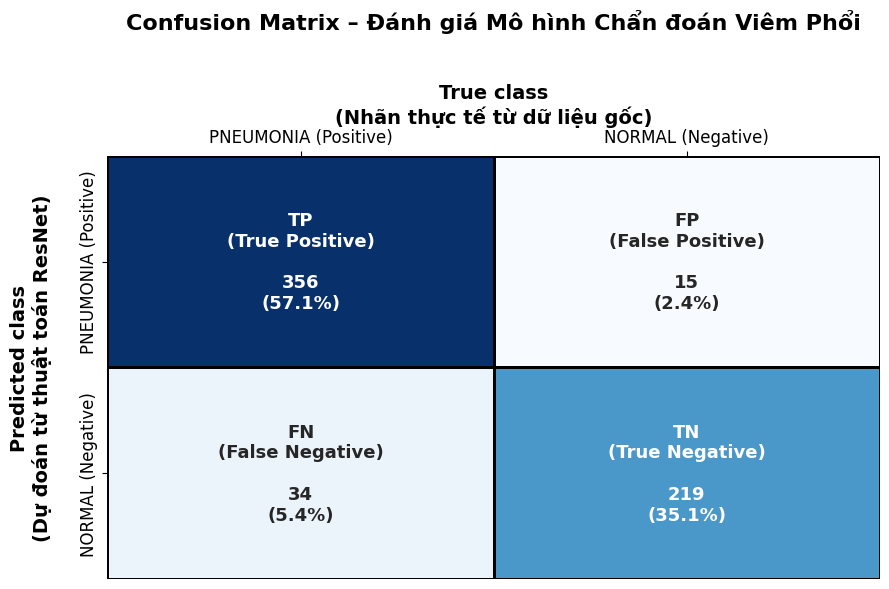

In [11]:

#TRỰC QUAN HÓA MA TRẬN NHẦM LẪN (CUSTOM CONFUSION MATRIX)
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

try:
    _ = cm
except NameError:
    raise NameError("❌ Biến 'cm' chưa tồn tại. Vui lòng chạy Khối 3 để đánh giá mô hình trước.")

def plot_academic_confusion_matrix(cm_sklearn):
    """
    Tái cấu trúc ma trận nhầm lẫn từ chuẩn scikit-learn sang chuẩn y khoa/lý thuyết.
    Đưa lớp Positive (PNEUMONIA) lên đầu và đảo trục Y=Predicted, X=True.
    """
    # 1. Trích xuất các giá trị cốt lõi từ ma trận sklearn
    # cm_sklearn format: [[TN, FP], [FN, TP]]
    TN = cm_sklearn[0, 0]
    FP = cm_sklearn[0, 1]
    FN = cm_sklearn[1, 0]
    TP = cm_sklearn[1, 1]

    # 2. Tái cấu trúc ma trận theo đúng thứ tự hình ảnh tham chiếu
    # Row 1 (Predicted Positive): [TP, FP]
    # Row 2 (Predicted Negative): [FN, TN]
    cm_custom = np.array([
        [TP, FP],
        [FN, TN]
    ])

    # 3. Tạo văn bản hiển thị cho từng ô (kèm theo giá trị và tỷ lệ % trên tổng tập Test)
    total = np.sum(cm_custom)
    labels = np.array([
        [f"TP\n(True Positive)\n\n{TP}\n({TP/total:.1%})", f"FP\n(False Positive)\n\n{FP}\n({FP/total:.1%})"],
        [f"FN\n(False Negative)\n\n{FN}\n({FN/total:.1%})", f"TN\n(True Negative)\n\n{TN}\n({TN/total:.1%})"]
    ])

    # 4. Thiết lập không gian vẽ đồ thị
    plt.figure(figsize=(9, 6))

    # 5. Khởi tạo heatmap với màu sắc phân biệt rõ ràng
    # Sử dụng cmap tùy chỉnh để mô phỏng màu sắc học thuật
    ax = sns.heatmap(cm_custom, annot=labels, fmt='', cmap="Blues",
                     cbar=False, annot_kws={"size": 13, "weight": "bold"},
                     linewidths=2, linecolor='black')

    # 6. Thiết lập tiêu đề và nhãn các trục
    ax.set_title("Confusion Matrix – Đánh giá Mô hình Chẩn đoán Viêm Phổi\n", fontsize=16, fontweight='bold')

    # Đặt tên trục (Lưu ý: Đã đảo ngược so với sklearn mặc định)
    ax.set_xlabel("\nTrue class\n(Nhãn thực tế từ dữ liệu gốc)", fontsize=14, fontweight='bold')
    ax.set_ylabel("Predicted class\n(Dự đoán từ thuật toán ResNet)\n", fontsize=14, fontweight='bold')

    # 7. Thiết lập tên các cột và hàng
    # Trục X (True Class): Cột 1 = Positive, Cột 2 = Negative
    ax.xaxis.set_ticklabels(['PNEUMONIA (Positive)', 'NORMAL (Negative)'], fontsize=12)
    ax.xaxis.tick_top() # Đưa nhãn trục X lên trên giống hình mẫu
    ax.xaxis.set_label_position('top')

    # Trục Y (Predicted Class): Hàng 1 = Positive, Hàng 2 = Negative
    ax.yaxis.set_ticklabels(['PNEUMONIA (Positive)', 'NORMAL (Negative)'], fontsize=12, rotation=90, va='center')

    # 8. Tối ưu hiển thị
    plt.tight_layout()
    plt.show()

# Thực thi hàm hiển thị
print("📊 Đang khởi tạo biểu đồ Ma trận nhầm lẫn...")
plot_academic_confusion_matrix(cm)